In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:
data = load_diabetes()

In [4]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [5]:
#map into dataframe format for better visualization
x =pd.DataFrame(data.data,columns=data.feature_names)
y =data.target

In [6]:
features = ['bmi','bp', 's5']
X = x[features]

In [7]:
X_train,X_test,Y_train,Y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(X_test)

          bmi        bp        s5
212  0.003494  0.035644 -0.000612
422  0.077863  0.052858  0.040673
67  -0.014828 -0.017135 -0.011897
89  -0.048241 -0.019442 -0.024795
390  0.069241  0.059744  0.103297
..        ...       ...       ...
129  0.016428  0.004658  0.038968
417  0.071397 -0.074527 -0.046883
332  0.104809  0.076958  0.057108
150  0.070319  0.025315 -0.019198
192 -0.030996  0.008101 -0.029526

[89 rows x 3 columns]


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
def costfunction(y_actual, y_predict):
  m= len(y_actual)
  sum = np.sum((y_predict - y_actual)*2)
  return (sum/(2*m))

In [10]:
#polynomial regression
degree=range(1,7)
cost_values=[]
for deg in degree:
    poly=PolynomialFeatures(degree=deg,include_bias=False)
    x_train_poly=poly.fit_transform(X_train)
    x_test_poly=poly.transform(X_test)

    #scaling again the polynomial features...
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(x_train_poly)
    X_test_poly = scaler.transform(x_test_poly)
    model=LinearRegression()
    model.fit(X_train_poly,Y_train)
    y_pred=model.predict(X_test_poly)

    cost=costfunction(Y_test,y_pred)
    cost_values.append(cost)

    print(f"Degree{deg}Cost={cost:.2f}")

Degree1Cost=-0.96
Degree2Cost=-1.92
Degree3Cost=-5.31
Degree4Cost=-4.60
Degree5Cost=-2.45
Degree6Cost=6.27


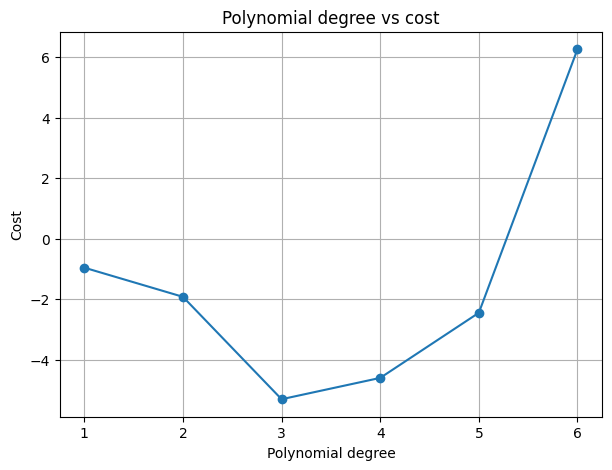

In [12]:
plt.figure(figsize=(7,5))
plt.plot(list(degree), cost_values, marker='o')
plt.xlabel("Polynomial degree")
plt.ylabel("Cost")
plt.title("Polynomial degree vs cost")
plt.grid(True)
plt.show()